In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
from scarf.plotting import CellField

scarf.configure_output(level="ERROR", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
merged_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{merged_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
baseline = ds.pipeline.open(label="docs_default")

normalized = baseline["normalized"]
pca_full = baseline["pca"]
uncorrected_neighbors = baseline["neighbors"]
uncorrected_graph = baseline["connectivity_map"]


def integration_scores(neighbors, graph):
    return {
        "iLISI": ds.metric_ilisi(
            batch_colname="sample_id",
            neighbors=neighbors,
            perplexity=7,
        ),
        "cLISI": ds.metric_clisi(
            annotation_column="orig_cluster_labels",
            neighbors=neighbors,
            perplexity=7,
        ),
        "graph connectivity": ds.metric_graph_connectivity(
            annotation_column="orig_cluster_labels",
            graph=graph,
        ),
    }


scores = {
    "Uncorrected": integration_scores(
        uncorrected_neighbors,
        uncorrected_graph,
    )
}

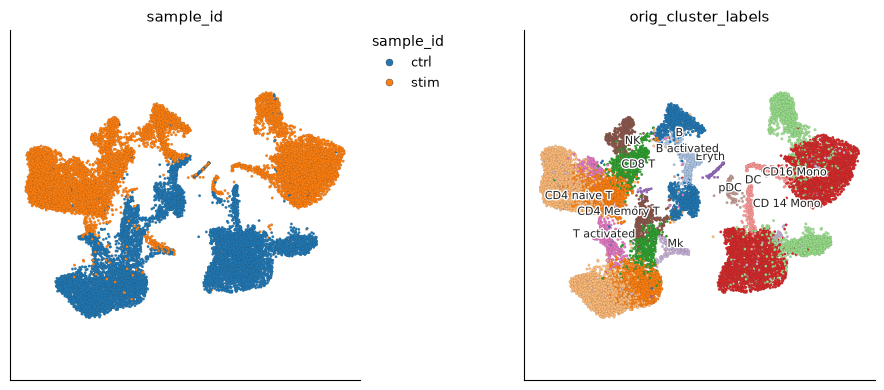

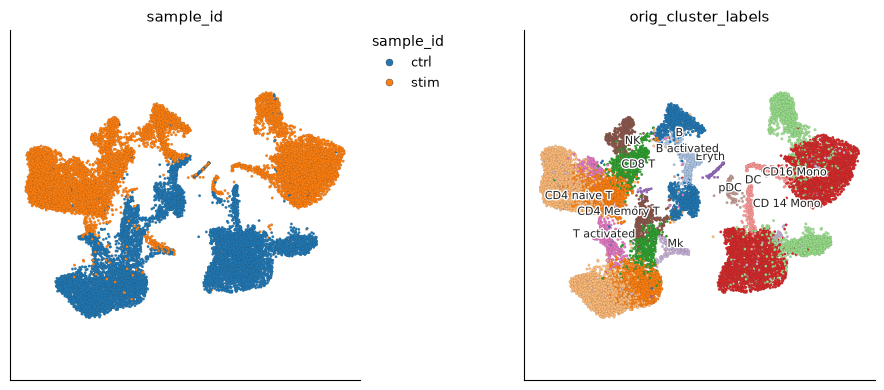

In [2]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, color_by in zip(
    axes,
    ("sample_id", "orig_cluster_labels"),
    strict=True,
):
    ds.plots.embedding(
        run=baseline,
        layout="umap",
        color_by=color_by,
        target=axis,
        show=False,
    )
figure.tight_layout()
figure

In [3]:
pd.crosstab(
    baseline.cells.fetch("clusters"),
    baseline.cells.fetch("sample_id"),
    normalize="index",
)

col_0,ctrl,stim
row_0,,
1,0.007924,0.992076
2,0.003753,0.996247
3,0.002387,0.997613
4,0.416244,0.583756
5,0.003844,0.996156
6,0.434896,0.565104
7,0.590323,0.409677
8,0.431853,0.568147
9,0.005875,0.994125


In [4]:
pd.Series(scores["Uncorrected"]).round(3).rename("Uncorrected")

iLISI                 0.000
cLISI                 0.999
graph connectivity    0.983
Name: Uncorrected, dtype: float64

In [5]:
baseline_active = baseline.cells.fetch_all("I").astype(bool)
is_ctrl = baseline_active & (baseline.cells.fetch_all("sample_id") == "ctrl")
ds.cells.insert(
    column_name="is_ctrl",
    values=is_ctrl,
    overwrite=True,
)
pd.Series(
    {
        "active cells": int(baseline_active.sum()),
        "reference (is_ctrl)": int(is_ctrl.sum()),
        "reference fraction": round(float(is_ctrl[baseline_active].mean()), 3),
    }
)

active cells           18597.000
reference (is_ctrl)     8486.000
reference fraction         0.456
dtype: float64

In [6]:
pca_partial = ds.run_pca(
    normalized,
    dims=25,
    pca_cell_selection=ds.snapshot_cell_selection(cell_key="is_ctrl"),
)
partial_initialization = ds.build_embedding_initialization(pca_partial)
partial_neighbors = ds.query_neighbors(
    ds.build_ann_index(pca_partial),
    k=21,
)
partial_graph = ds.build_connectivity_map(partial_neighbors)
partial_umap = ds.run_umap(
    partial_graph,
    partial_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
partial_clusters = ds.run_leiden_clustering(
    partial_graph,
    resolution=1.0,
)
scores["Partial PCA"] = integration_scores(
    partial_neighbors,
    partial_graph,
)

In [7]:
partial_umap_values = np.asarray(ds.load_artifact(partial_umap)["values"][:])
partial_cluster_values = np.asarray(
    ds.load_artifact(partial_clusters)["values"][:]
)

In [8]:
corrected = ds.run_harmony(pca_full, ["sample_id"])
harmony_initialization = ds.build_embedding_initialization(corrected)
harmony_neighbors = ds.query_neighbors(
    ds.build_ann_index(corrected),
    k=21,
)
harmony_graph = ds.build_connectivity_map(harmony_neighbors)
harmony_umap = ds.run_umap(
    harmony_graph,
    harmony_initialization,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
harmony_clusters = ds.run_leiden_clustering(
    harmony_graph,
    resolution=1.0,
)
scores["Harmony"] = integration_scores(
    harmony_neighbors,
    harmony_graph,
)

In [9]:
harmony_umap_values = np.asarray(ds.load_artifact(harmony_umap)["values"][:])
harmony_cluster_values = np.asarray(
    ds.load_artifact(harmony_clusters)["values"][:]
)

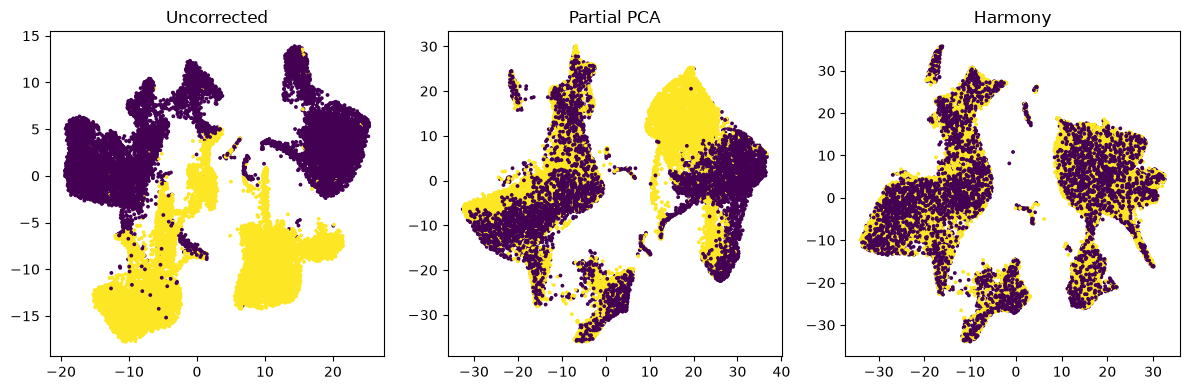

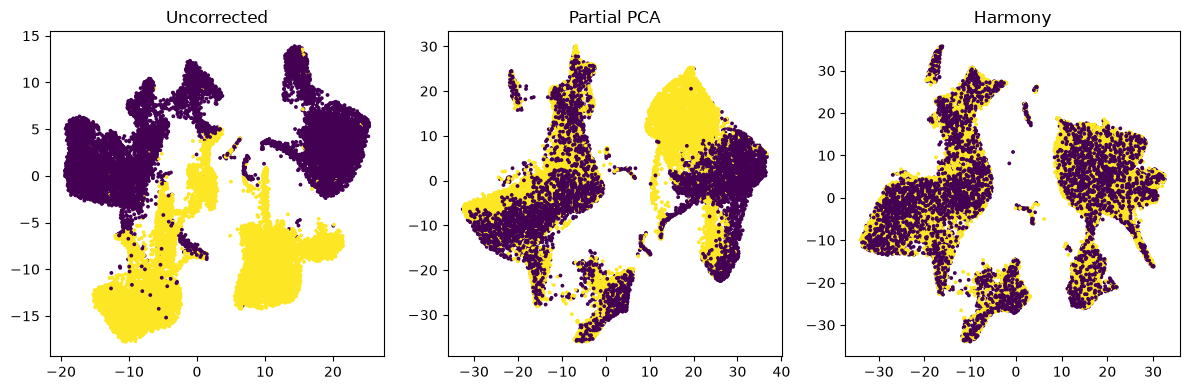

In [10]:
baseline_frame = baseline.cells.to_pandas_dataframe(
    ["umap_1", "umap_2", "sample_id", "orig_cluster_labels", "clusters"]
)
baseline_umap_values = baseline_frame[["umap_1", "umap_2"]].to_numpy()
layout_values = (baseline_umap_values, partial_umap_values, harmony_umap_values)
sample_codes = pd.factorize(baseline_frame["sample_id"])[0]

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, coordinates, title in zip(
    axes,
    layout_values,
    ("Uncorrected", "Partial PCA", "Harmony"),
    strict=True,
):
    axis.scatter(coordinates[:, 0], coordinates[:, 1], c=sample_codes, s=3)
    axis.set_title(title)
figure.tight_layout()
figure

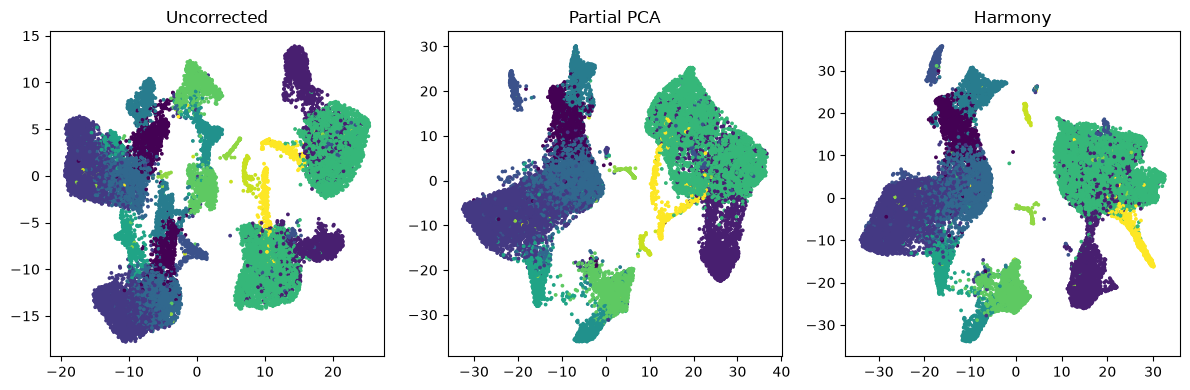

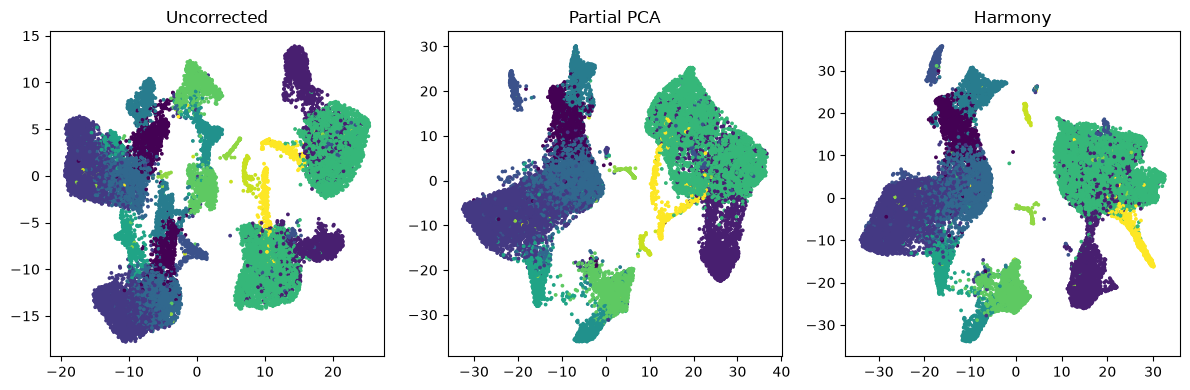

In [11]:
label_codes = pd.factorize(baseline_frame["orig_cluster_labels"])[0]
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, coordinates, title in zip(
    axes,
    layout_values,
    ("Uncorrected", "Partial PCA", "Harmony"),
    strict=True,
):
    axis.scatter(coordinates[:, 0], coordinates[:, 1], c=label_codes, s=3)
    axis.set_title(title)
figure.tight_layout()
figure

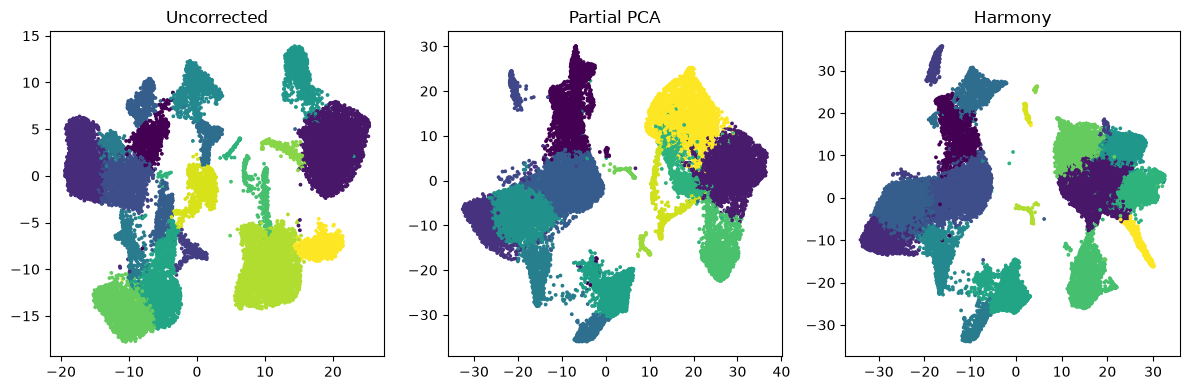

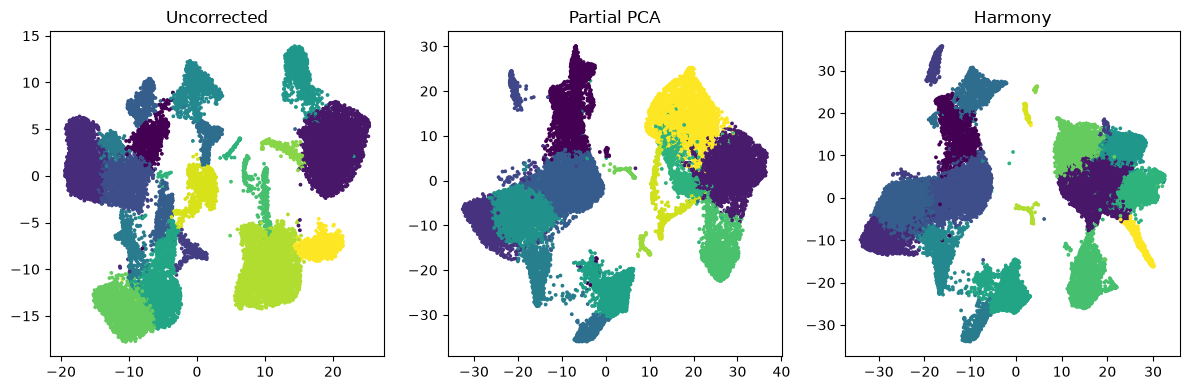

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
cluster_panels = (
    ("Uncorrected", baseline_umap_values, baseline_frame["clusters"].to_numpy()),
    ("Partial PCA", partial_umap_values, partial_cluster_values),
    ("Harmony", harmony_umap_values, harmony_cluster_values),
)
for axis, (title, coordinates, values) in zip(
    axes, cluster_panels, strict=True
):
    axis.scatter(coordinates[:, 0], coordinates[:, 1], c=values, s=3)
    axis.set_title(title)
figure.tight_layout()
figure

In [13]:
pd.concat(
    {
        title: pd.crosstab(values, baseline_frame["sample_id"], normalize="index")
        for title, _coordinates, values in cluster_panels
    }
)

sample_id              ctrl      stim
            row_0                    
Uncorrected 1      0.007924  0.992076
            2      0.003753  0.996247
            3      0.002387  0.997613
            4      0.416244  0.583756
            5      0.003844  0.996156
            6      0.434896  0.565104
            7      0.590323  0.409677
            8      0.431853  0.568147
            9      0.005875  0.994125
            10     0.010574  0.989426
            11     0.976714  0.023286
            12     0.407895  0.592105
            13     0.771242  0.228758
            14     0.990868  0.009132
            15     0.005128  0.994872
            16     0.997487  0.002513
            17     0.995569  0.004431
            18     0.998333  0.001667
Partial PCA 1      0.401204  0.598796
            2      0.062429  0.937571
            3      0.499042  0.500958
            4      0.400844  0.599156
            5      0.488312  0.511688
            6      0.498652  0.501348
            7      0.440860  0.559140
            8      0.376088  0.623912
            9      0.448746  0.551254
            10     0.493455  0.506545
            11     0.449874  0.550126
            12     0.395349  0.604651
            13     0.356522  0.643478
            14     0.544503  0.455497
            15     0.969671  0.030329
Harmony     1      0.390612  0.609388
            2      0.462604  0.537396
            3      0.433071  0.566929
            4      0.432787  0.567213
            5      0.455058  0.544942
            6      0.426170  0.573830
            7      0.432783  0.567217
            8      0.471744  0.528256
            9      0.451444  0.548556
            10     0.577342  0.422658
            11     0.456790  0.543210
            12     0.507937  0.492063
            13     0.480253  0.519747
            14     0.455469  0.544531
            15     0.411765  0.588235
            16     0.428571  0.571429
            17     0.386792  0.613208
            18     0.478261  0.521739

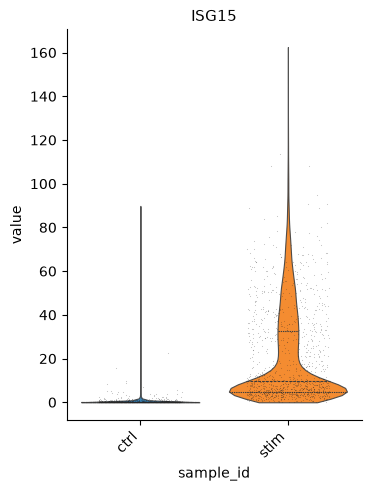

In [14]:
ds.plots.distribution(
    keys="ISG15",
    grouping=CellField("sample_id"),
    cell_selection=baseline["analysis_cell_selection"],
    kind="violin",
    max_points=2000,
    seed=0,
)

In [15]:
score_frame = pd.DataFrame.from_dict(scores, orient="index")
score_frame.round(3)

,iLISI,cLISI,graph connectivity
Uncorrected,0.000,0.999,0.983
Partial PCA,0.024,0.999,0.986
Harmony,0.503,0.999,0.981
